In [2]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [45]:
import yfinance as yf
msft_data = yf.Ticker('MSFT')
df = msft_data.history(start='2020-01-01') 
df.head()
df.dropna()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1644.0,3.224576e+02,1.003623e+02,1.298654e+02,2.380772e+02,3.122166e+02,4.091445e+02,5.508301e+02
High,1644.0,3.255953e+02,1.007757e+02,1.332398e+02,2.411433e+02,3.151245e+02,4.116389e+02,5.510484e+02
Low,1644.0,3.191622e+02,9.970448e+01,1.256096e+02,2.363710e+02,3.087726e+02,4.046752e+02,5.373667e+02
Close,1644.0,3.225056e+02,1.002486e+02,1.283583e+02,2.392247e+02,3.127219e+02,4.084648e+02,5.386585e+02
Volume,1644.0,2.838366e+07,1.326756e+07,5.855900e+06,2.006522e+07,2.522970e+07,3.286818e+07,1.862016e+08
Dividends,1644.0,1.096107e-02,8.796849e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.100000e-01
Stock Splits,1644.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [37]:
target = 'Open'
X = df.drop(columns=target)
y = df[target]

X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X.shape); print(y.shape)

(10165, 6)
(10165,)


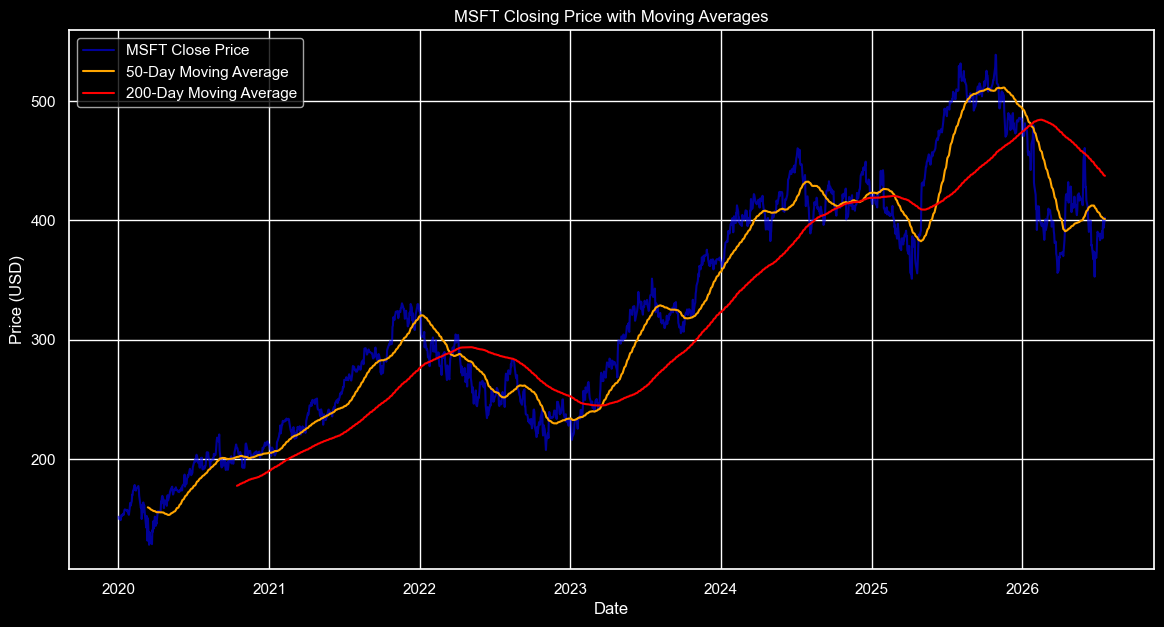

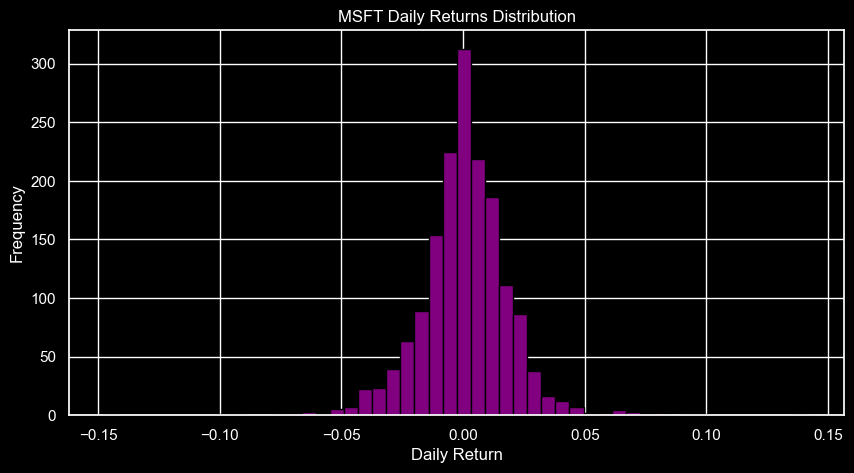

In [50]:
msft_data.columns = msft_data.columns.get_level_values(0)

# 2. Visualize Closing Price and Moving Averages
msft_data['MA_50'] = msft_data['Close'].rolling(window=50).mean() 
msft_data['MA_200'] = msft_data['Close'].rolling(window=200).mean() 

plt.style.use('dark_background')
plt.figure(figsize=(14, 7)) 
plt.plot(msft_data['Close'], label='MSFT Close Price', color='blue', alpha=0.6) 
plt.plot(msft_data['MA_50'], label='50-Day Moving Average', color='orange') 
plt.plot(msft_data['MA_200'], label='200-Day Moving Average', color='red') 
plt.title('MSFT Closing Price with Moving Averages') 
plt.xlabel('Date') 
plt.ylabel('Price (USD)') 
plt.legend() 
plt.show() 

# 3. Analyze Daily Returns 
msft_data['Daily_Return'] = msft_data['Close'].pct_change() 

plt.figure(figsize=(10, 5)) 
plt.hist(msft_data['Daily_Return'].dropna(), bins=50, color='purple', edgecolor='black') 
plt.title('MSFT Daily Returns Distribution') 
plt.xlabel('Daily Return') 
plt.ylabel('Frequency') 
plt.show()


In [ ]:
file_name = 'df_processed.csv'
df.to_csv(file_name, index=False)
print(f'Saved as: {file_name}')

file_name2 = 'df_raw.csv'
df_raw = msft_data
df_raw.to_csv('df_raw.csv', index=False)
print(f'Saved as: {file_name2}')

Saved as: df_processed.csv
Saved as: df_raw.csv
